In [1]:
# pip install pystokes

## Example 1 : sedimentation of no-slip spheres

* In this example, we study the sedimentation of no-slip (or passive) spheres.
* We will use the `mobilityTT(v, r, F)` method of PyStokes
* We first explain the math behind this function

In [9]:
## import pystokes
import pystokes


## import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

## Velocity of one sedimenting sphere

$$\mathbf{V} =\mu^T_0\,\mathbf{F}
$$

It is useful to note that

$$
\mu_0^T  =\frac{1}{6\pi\eta b}
$$

## Velocity of $2$ sedimenting no-slip spheres

$$\mathbf{V}_1 =\mu^T_{11}\cdot\mathbf{F}_1+\boldsymbol \mu^{TT}_{12}\cdot\mathbf{F}_2,$$

$$\mathbf{V}_2 =\mu^T_{22}\cdot\mathbf{F}_2+\boldsymbol \mu^{TT}_{21}\cdot\mathbf{F}_1,$$


Here, we have defined

$$\boldsymbol \mu^{TT}_{12} = \left(1+\frac{b^2}3 \nabla^2 \right) \boldsymbol {G} (\boldsymbol{R}_1-\boldsymbol{R}_2). $$

Here $\boldsymbol R_i$ is the location of the $i$th N and $\boldsymbol {G}$ is a tensor of rank 2. It is given as:

$$
G_{\alpha\beta}=\frac{1}{8\pi\eta}\left(\frac{\delta_{\alpha\beta}}{r_{12}}
+\frac{(r_{12})_{\alpha}(r_{12})_{\beta}}{r^3_{12}}\right)
$$

We uses:
* Greek indices, $\alpha,\beta$ to indicate N indices
* Roman indices, $i, j$ to indicate Cartesian indices

It is useful to note that

$$
\boldsymbol\mu_{11}^{TT} =\mu_0^T \, \mathbf I=\frac{1}{6\pi\eta b}\mathbf I
$$

Here $\mathbf I$ is the identity tensor. We will assume spheres of equal sizes. Thus,

$$
\boldsymbol\mu_{ii}^{TT} =\mu_0^T \, \mathbf I=\frac{1}{6\pi\eta b}\mathbf I
$$

## Velocity of $N$ sedimenting no-slip spheres

$$\mathbf{V}_{\alpha} =\sum_\beta \boldsymbol \mu^{TT}_{\alpha\beta}\cdot\mathbf{F}_\beta,$$

The above is the quantity which PyStokes compute when you call `mobilityTT(v, r, F)`.

In [10]:
# N radius, fluid viscosity, and number of particles
b, eta, N = 1.0, 1.0/(6.0*np.pi), 1

f0=-1. ## stength of the force


#initialise position,  and body force on the colloid
r, F = np.array([0.0, 0.0, 0.0]),  np.array([0.0, 0.0, f0])

In [11]:
# instantiate the RBM(Rigid body motio) class
rbm = pystokes.unbounded.Rbm(radius=b, particles=N, viscosity=eta)

In [12]:
v = np.array([0.0, 0.0, 0.0])

print (v)
v=v*0
rbm.mobilityTT(v, r, F)
print (v)


[0. 0. 0.]
[ 0.  0. -1.]


## Simulation of two sedimenting colloidal spheres

## Simulate the two-body dynamics

We now simualte the dynamics
* xt1 stores x-corrds of N 1
* xt2 stores x-corrds of N 2
* zt1 stores z-corrds of N 1
* zt2 stores z-corrds of N 2

In [13]:
def simulateSedimentation(r, Nt, dt, N):
    """
    r: initial position of the particle
    Nt: total number of time point
    dt: time-step
    N: number of particles
    """
    rbm = pystokes.unbounded.Rbm(radius=b, particles=N, viscosity=eta)
    xt1 = np.zeros(Nt+1)
    zt1 = np.zeros(Nt+1)
    xt2 = np.zeros(Nt+1)
    zt2 = np.zeros(Nt+1)
    
    ## set initial conditon
    xt1[0], xt2[0] = r[0], r[1]
    zt1[0], zt2[0] = r[4], r[5]

    for i in trange(Nt):
      v = np.zeros(3*N)
      F = np.zeros(3*N)
      F[2*N:3*N]=f0
      rbm.mobilityTT(v, r, F)
    
      xt1[i+1] = xt1[i] + v[0]*dt
      xt2[i+1] = xt2[i] + v[1]*dt
    
      zt1[i+1] = zt1[i] + v[4]*dt
      zt2[i+1] = zt2[i] + v[5]*dt
    
      r[0] = xt1[i+1]
      r[1] = xt2[i+1]
      r[4] = zt1[i+1]
      r[5] = zt2[i+1]
    return xt1, xt2, zt1, zt2

## Add some parameters

In [14]:
N=2
Nt = int(1.12e4) ## number of time points
dt = 0.01
r = np.zeros(3*N)

## Plot the trajectory and color with time

Simulation with initial condition 1


100%|██████████████████████████████████████████████████████| 11200/11200 [00:00<00:00, 176252.42it/s]


Simulation with initial condition 3


100%|██████████████████████████████████████████████████████| 11200/11200 [00:00<00:00, 302556.97it/s]


Simulation with initial condition 3


100%|██████████████████████████████████████████████████████| 11200/11200 [00:00<00:00, 301502.53it/s]


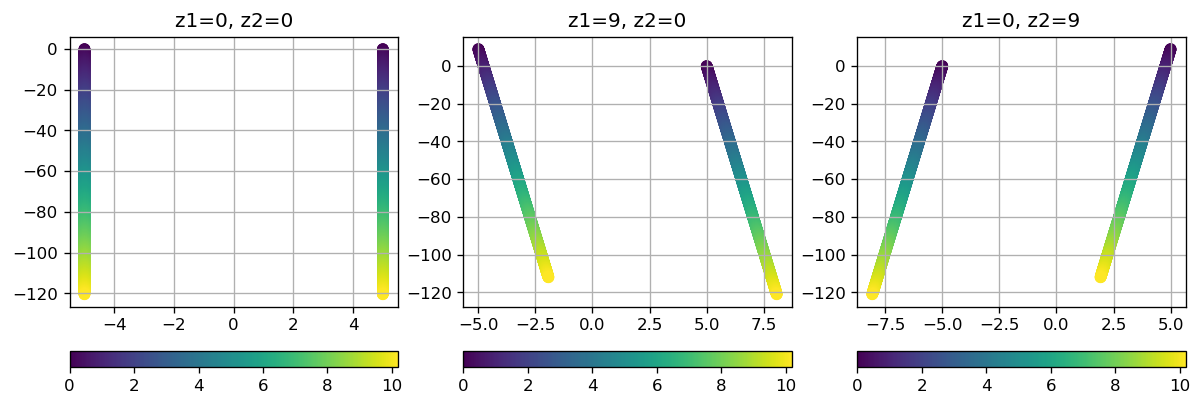

In [15]:
fig = plt.figure(figsize=(12, 4), dpi=120);




plt.subplot(131)
print ('Simulation with initial condition 1')
## Initial position 1
r[0], r[1],  = -5, 5.    ## x position
r[4], r[5] = 0., 0.

xt1, xt2, zt1, zt2 = simulateSedimentation(r, Nt, dt, N)
dd=11 ## plot every 11th time-point
plt.scatter(xt1[::dd], zt1[::dd], c=dt*np.arange(xt1[::dd].size))
plt.scatter(xt2[::dd], zt2[::dd], c=dt*np.arange(xt1[::dd].size))

cbar=plt.colorbar(location='bottom', pad=0.12);  plt.grid();  plt.title('z1=0, z2=0')


plt.subplot(132)
print ('Simulation with initial condition 3')
## Initial position 1
r[0], r[1],  = -5, 5.    ## x position
r[4], r[5] = 9., 0.

xt1, xt2, zt1, zt2 = simulateSedimentation(r, Nt, dt, N)
dd=11 ## plot every 11th time-point
plt.scatter(xt1[::dd], zt1[::dd], c=dt*np.arange(xt1[::dd].size))
plt.scatter(xt2[::dd], zt2[::dd], c=dt*np.arange(xt1[::dd].size))

cbar=plt.colorbar(location='bottom', pad=0.12);  plt.grid();   plt.title('z1=9, z2=0')



plt.subplot(133)
print ('Simulation with initial condition 3')
## Initial position 1
r[0], r[1],  = -5, 5.    ## x position
r[4], r[5] = 0., 9.

xt1, xt2, zt1, zt2 = simulateSedimentation(r, Nt, dt, N)
dd=11 ## plot every 11th time-point
plt.scatter(xt1[::dd], zt1[::dd], c=dt*np.arange(xt1[::dd].size))
plt.scatter(xt2[::dd], zt2[::dd], c=dt*np.arange(xt1[::dd].size))

cbar=plt.colorbar(location='bottom', pad=0.12);  plt.grid();  plt.title('z1=0, z2=9') ;